# **Grid World**

### 1. Setup



The grid world is a classic example demonstrating reinforcement learning. An agent must traverse a grid from a starting pixel to an ending pixel while avoiding traps in the most optimal path. In most cases, the optimal path is roughly the shortest path that avoids the risk of falling into traps to some degree. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### 2. Value Iteration

In the previous notebook, we presented the Bellman optimality equation for the optimal state-value function $V(s) = v_{\Pi^*}(s)$ as,

$$
\Longrightarrow V(s) = \underset{a}{\max}  \left( \sum_{s' \in S} \sum_{r \in \mathcal{R}} p(s', r \vert s, a) [r + \gamma V(s')] \right)
$$

The key insight was that succesive states in the trajectory governed by the optimal policy are related to each other via this recursive relationship. Value iteration approximates $V(s)$ to a sufficient degree by repeatedly applying the Bellman optimality equation to an initial estimate of the value function. Starting from an arbitrary value function $V_0(s)$, the value of each state $s$ is updated according to:

$$
V_{k+1}(s) = \underset{a}{\max} \left( \sum_{s' \in S} \sum_{r \in \mathcal{R}} p(s', r \mid s, a) \left[r + \gamma V_k(s') \right] \right)
$$

where $k$ denotes the iteration number. At each iteration, the value of a state is replaced by the maximum expected return obtainable from that state, assuming the current estimate $V_k(s)$ is correct for all successor states. Repeated application of this update propagates information about future rewards backwards through the state space. Under suitable conditions, the sequence of value functions $\{V_k\}$ converges to the optimal value function $V$, from which the optimal policy can be recovered by selecting, at each state, the action that maximises the Bellman optimality equation. In the context of the grid world example, each state $s$ of the environment corresponds to the agent occupying a particular cell of the grid. Hence, we have a state value $V$ for each cell of the grid that quantifies the expected return of the agent starting there. Note that reward given to the agent after taking an action $a$ that causes the transition $s \rightarrow s'$ is fixed. That is, the reward is only dependent on the state $s'$,

$$
V_{k+1}(s) = \underset{a}{\max} \left( \sum_{s' \in S} p(s', \mid s, a) \left[r(s') + \gamma V_k(s') \right] \right)
$$

Further simplification can be made if actions cause deterministic transitions such that each action $a$ from state $s$ leads to a single fixed next state $s'_{a}$. In this case, the sum collapses because only one transition is possible. Our value iteration equation is then, 

$$
V_{k+1}(s) = r(s') + \gamma \underset{a}{\max} \left[ V_k(s'_{a}) \right]
$$

Assuming this form of the value iteration equation, the puesdocode for value iteration is then, 

### 3. Simulation

Let us first create the grid world,

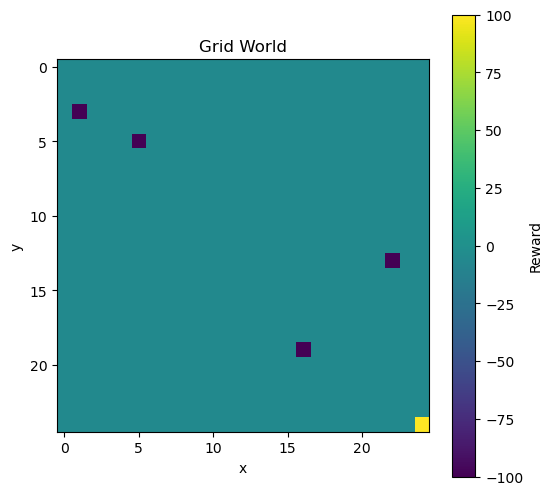

In [55]:
# World settings,
WORLD_SIZE = 25
AGENT_LOC = (0, 0)
GOAL_LOC = (WORLD_SIZE-1, WORLD_SIZE-1)
N_TRAPS = 5
ALPHA = -5

# Initialising grid,
grid = ALPHA*np.ones(shape=(WORLD_SIZE, WORLD_SIZE))

# Creating random traps,
trap_locs = []
for trap in range(N_TRAPS):
    trap_loc = np.random.randint(low=0, high=WORLD_SIZE-1, size=2)
    grid[trap_loc[0], trap_loc[1]] = -100
    trap_locs.append(trap_loc)

# Adding agent and ending locations,
grid[AGENT_LOC] = ALPHA
grid[GOAL_LOC] = 100

# Displaying the grid world,
def plot_grid(grid):
    grid_plot = grid.copy()
    grid_plot[np.isneginf(grid_plot)] = -10 # Traps
    grid_plot[np.isposinf(grid_plot)] = 10  # Goal
    plt.figure(figsize=(6, 6))
    im = plt.imshow(grid_plot, cmap="viridis")
    plt.colorbar(im, label="Reward")
    plt.title("Grid World")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_grid(grid=grid)

Now we create the `Environment` and `Agent` class give us an interface to move the agent across the grid world. The `Environment` handles updating the state of the environment in response to the movement of the agent. We can imagine it as a basic world engine to simulate the environment the agent is in.

In [56]:
class Environment():

    # Actions,
    ACTIONS = {
        "up": (-1, 0),
        "down": (1, 0),
        "left": (0, -1),
        "right": (0, 1),
    }

    def __init__(self, world_size, alpha, n_traps, goal_loc, agent_loc):

        # Assigning class attributes,
        self.world_size = world_size
        self.alpha = alpha
        self.n_traps = n_traps
        self.goal_loc = goal_loc
        self.agent_loc = agent_loc

        # Creating trap locations,
        trap_locs = []
        for i in range(n_traps):
            trap_loc = np.random.randint(low=0, high=WORLD_SIZE-1, size=2)
            trap_locs.append(trap_loc)
        self.trap_locs = trap_locs

        # Creating grid world,
        self.grid = self._create_grid_(world_size, alpha, trap_locs, goal_loc, agent_loc)

    def update(self, action):
        """Updates the environment state based on the new location of the agent."""

        # Updating agent location,
        dx, dy = self.ACTIONS[action]
        self.agent_loc[0] += dx
        self.agent_loc[1] += dy

        # Updating environment state,
        reward = self.grid[tuple(self.agent_loc)] # <-- Reward for the agent.
        self.grid = self._create_grid_(self.world_size, self.alpha, self.trap_locs, self.goal_loc, self.agent_loc)

        return self.grid.copy(), reward

    def _create_grid_(self, world_size, alpha, trap_locs, goal_loc, agent_loc):
        """Constructs the environment state given the location of the agent."""

        # Creating grid world,
        grid = alpha*np.ones(shape=(world_size, world_size))

        # Creating random traps,
        for trap_loc in trap_locs:
            grid[tuple(trap_loc)] = -100

        # Adding agent and goal locations,
        grid[tuple(agent_loc)] = self.alpha
        grid[goal_loc] = 100

        return grid

class Agent():

    def __init__(self, env):

        # Assigning class attributes,
        self.env = env
        self.total_reward = 0

    def act(self, action):
        state, reward = self.env.update(action)
        self.total_reward += reward
        return state, reward

The boilerplate code to create the environment,

In [69]:
# World settings,
WORLD_SIZE = 5
AGENT_LOC = [0, 0]
GOAL_LOC = (WORLD_SIZE-1, WORLD_SIZE-1)
N_TRAPS = 5
ALPHA = -1

# Creating agent and environment,
env = Environment(world_size=WORLD_SIZE, alpha=ALPHA, n_traps=N_TRAPS, goal_loc=GOAL_LOC, agent_loc=AGENT_LOC)
agent = Agent(env)

### 4. Performing Value Iteration

Let us create the initial optimal-value function $V_0(s)$,

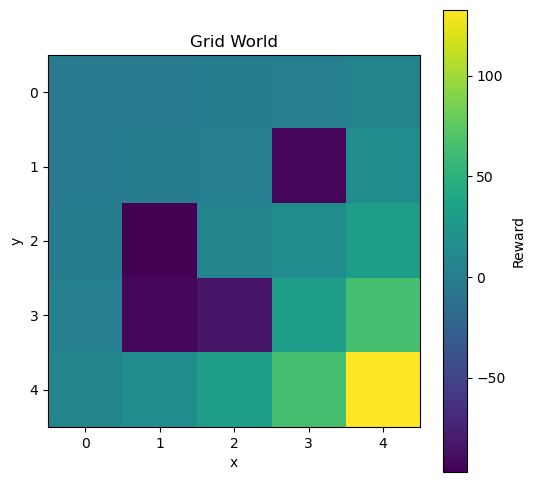

In [70]:
GAMMA=0.5
N = 1000

# Initialising V_0,
v_0 = np.zeros(shape=(WORLD_SIZE, WORLD_SIZE))

for N in range(N):
    for i in range(v_0.shape[0]):
        for j in range(v_0.shape[1]):

            neighbours = []
            # Up
            if i > 0:
                neighbours.append(v_0[i-1, j])

            # Down
            if i < v_0.shape[0] - 1:
                neighbours.append(v_0[i+1, j])

            # Left
            if j > 0:
                neighbours.append(v_0[i, j-1])

            # Right
            if j < v_0.shape[1] - 1:
                neighbours.append(v_0[i, j+1])
            
            max_neighbour = max(neighbours)
            reward = env.grid[i, j]
            new_value = reward + GAMMA*max_neighbour
            v_0[i, j] = new_value

plot_grid(grid=v_0)